# Einfache Grid World mit Value Iteration

Dieses Notebook zeigt ein **sehr einfaches** Beispiel für:
- eine kleine **Grid World**
- **Hindernisse**
- einen **Startzustand**
- einen **Terminalzustand**
- **Value Iteration**, um die beste Policy zu berechnen

Die Idee:
Der Agent startet links oben, möchte rechts unten zum Ziel und soll Hindernisse vermeiden.

## 1. Bibliotheken und Grundparameter

Wir verwenden nur:
- `numpy`
- `matplotlib`

Die Grid World ist **5 x 5** groß.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Grid-Größe
ROWS, COLS = 5, 5

# Zustände
start_state = (0, 0)
terminal_state = (4, 4)

# Hindernisse (0-basiert)
obstacles = {
    (2, 2), (2, 3), (2, 4),
    (3, 2)
}

# Aktionen
actions = {
    "up":    (-1,  0),
    "down":  ( 1,  0),
    "left":  ( 0, -1),
    "right": ( 0,  1),
}

# RL-Parameter
gamma = 0.9
step_reward = -1.0
goal_reward = 10.0

all_states = [(r, c) for r in range(ROWS) for c in range(COLS)]

def is_inside(state):
    r, c = state
    return 0 <= r < ROWS and 0 <= c < COLS

def is_obstacle(state):
    return state in obstacles

def is_terminal(state):
    return state == terminal_state

Matplotlib is building the font cache; this may take a moment.


## 2. Übergangsfunktion

Hier definieren wir die Umweltlogik:

- Wenn der Agent gegen die Wand oder in ein Hindernis läuft, bleibt er stehen.
- Er bekommt pro Schritt eine kleine negative Belohnung (`-1`), damit kurze Wege bevorzugt werden.
- Wenn er das Ziel erreicht, bekommt er `+10`.

Das ist hier eine **deterministische** Grid World:
Für eine Aktion gibt es genau einen nächsten Zustand.

In [2]:
def next_state_and_reward(state, action_name):
    # Falls wir schon im Ziel sind, bleiben wir dort
    if is_terminal(state):
        return state, 0.0

    dr, dc = actions[action_name]
    r, c = state
    candidate = (r + dr, c + dc)

    # Ungültig oder Hindernis -> stehen bleiben
    if (not is_inside(candidate)) or is_obstacle(candidate):
        candidate = state

    # Belohnung
    if candidate == terminal_state:
        reward = goal_reward
    else:
        reward = step_reward

    return candidate, reward

## 3. Grid World zeichnen

Wir visualisieren:
- **rot** = Start
- **türkis** = Ziel
- **schwarz** = Hindernisse
- **weiß** = freie Felder

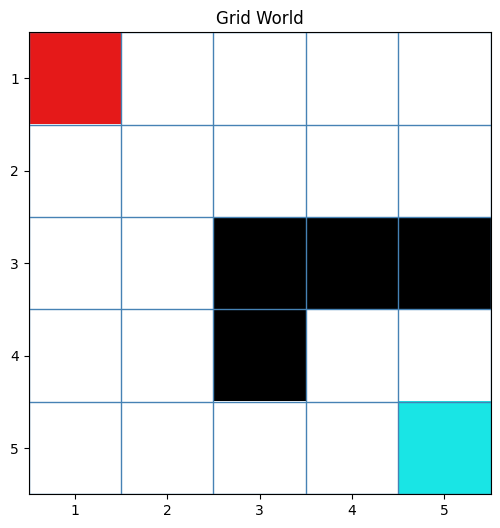

In [3]:
def draw_grid(ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # 0 = frei, 1 = Hindernis, 2 = Start, 3 = Ziel
    grid = np.zeros((ROWS, COLS))

    for r, c in obstacles:
        grid[r, c] = 1

    sr, sc = start_state
    tr, tc = terminal_state
    grid[sr, sc] = 2
    grid[tr, tc] = 3

    # Eigene Farbskala über einfache Masken
    color_grid = np.zeros((ROWS, COLS, 3))
    color_grid[:] = [1.0, 1.0, 1.0]  # frei = weiß

    for r, c in obstacles:
        color_grid[r, c] = [0.0, 0.0, 0.0]  # schwarz

    color_grid[sr, sc] = [0.9, 0.1, 0.1]   # rot
    color_grid[tr, tc] = [0.1, 0.9, 0.9]   # türkis

    ax.imshow(color_grid, origin="upper")

    # Gitterlinien
    ax.set_xticks(np.arange(-0.5, COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)
    ax.grid(which="minor", color="steelblue", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xticks(np.arange(COLS))
    ax.set_yticks(np.arange(ROWS))
    ax.set_xticklabels(np.arange(1, COLS + 1))
    ax.set_yticklabels(np.arange(1, ROWS + 1))
    ax.set_title("Grid World")
    return ax

fig, ax = plt.subplots(figsize=(6, 6))
draw_grid(ax)
plt.show()

## 4. Value Iteration

Die Update-Regel lautet:

\[
V_{k+1}(s) = \max_a \left( R(s,a,s') + \gamma V_k(s') \right)
\]

In dieser einfachen, deterministischen Grid World gibt es für jede Aktion nur **einen** Folgezustand.
Darum brauchen wir hier keine Summe über Wahrscheinlichkeiten.

Wir berechnen also für jeden Zustand:
1. alle möglichen Aktionswerte
2. nehmen den größten davon
3. wiederholen das, bis sich die Werte fast nicht mehr ändern

In [4]:
def value_iteration(theta=1e-6, max_iterations=1000):
    V = np.zeros((ROWS, COLS))
    policy = np.full((ROWS, COLS), "", dtype=object)

    for iteration in range(max_iterations):
        delta = 0.0
        new_V = V.copy()

        for state in all_states:
            r, c = state

            if is_obstacle(state):
                continue

            if is_terminal(state):
                new_V[r, c] = 0.0
                policy[r, c] = "TERM"
                continue

            action_values = {}

            for action_name in actions:
                next_state, reward = next_state_and_reward(state, action_name)
                nr, nc = next_state
                q = reward + gamma * V[nr, nc]
                action_values[action_name] = q

            best_action = max(action_values, key=action_values.get)
            best_value = action_values[best_action]

            new_V[r, c] = best_value
            policy[r, c] = best_action
            delta = max(delta, abs(V[r, c] - best_value))

        V = new_V

        if delta < theta:
            print(f"Konvergiert nach {iteration + 1} Iterationen.")
            return V, policy

    print("Maximale Iterationszahl erreicht.")
    return V, policy

V, policy = value_iteration()

print("Wertefunktion V:")
print(np.round(V, 2))

Konvergiert nach 11 Iterationen.
Wertefunktion V:
[[-0.43  0.63 -0.43 -1.39 -2.25]
 [ 0.63  1.81  0.63 -0.43 -1.39]
 [ 1.81  3.12  0.    0.    0.  ]
 [ 3.12  4.58  0.    8.   10.  ]
 [ 4.58  6.2   8.   10.    0.  ]]


## 5. Werte und optimale Policy visualisieren

Wir zeigen:
- die **Wertefunktion** als Heatmap
- die **beste Aktion** pro Feld als Pfeil

Pfeile:
- `↑` oben
- `↓` unten
- `←` links
- `→` rechts

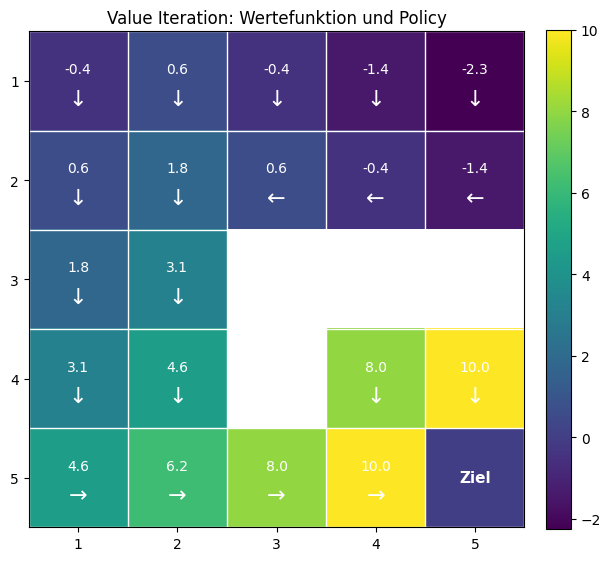

In [5]:
arrow_map = {
    "up": "↑",
    "down": "↓",
    "left": "←",
    "right": "→",
    "TERM": "G",
    "": ""
}

def plot_values_and_policy(V, policy):
    fig, ax = plt.subplots(figsize=(7, 7))
    display_V = V.copy()

    # Hindernisse als NaN, damit sie klar auffallen
    for r, c in obstacles:
        display_V[r, c] = np.nan

    im = ax.imshow(display_V, cmap="viridis", origin="upper")

    # Gitterlinien
    ax.set_xticks(np.arange(-0.5, COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xticks(np.arange(COLS))
    ax.set_yticks(np.arange(ROWS))
    ax.set_xticklabels(np.arange(1, COLS + 1))
    ax.set_yticklabels(np.arange(1, ROWS + 1))
    ax.set_title("Value Iteration: Wertefunktion und Policy")

    for r in range(ROWS):
        for c in range(COLS):
            state = (r, c)

            if state in obstacles:
                ax.text(c, r, "X", ha="center", va="center", color="white", fontsize=14, fontweight="bold")
            elif state == terminal_state:
                ax.text(c, r, "Ziel", ha="center", va="center", color="white", fontsize=11, fontweight="bold")
            else:
                arrow = arrow_map.get(policy[r, c], "")
                value_text = f"{V[r, c]:.1f}"
                ax.text(c, r - 0.12, value_text, ha="center", va="center", color="white", fontsize=10)
                ax.text(c, r + 0.18, arrow, ha="center", va="center", color="white", fontsize=16)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

plot_values_and_policy(V, policy)

## 6. Pfad aus der gelernten Policy simulieren

Wir starten im Startzustand und folgen immer der besten Aktion.

In [6]:
def simulate_policy(policy, start_state, max_steps=50):
    state = start_state
    path = [state]

    for _ in range(max_steps):
        if is_terminal(state):
            break

        r, c = state
        action_name = policy[r, c]

        if action_name in ("", "TERM"):
            break

        state, _ = next_state_and_reward(state, action_name)
        path.append(state)

        if is_terminal(state):
            break

    return path

path = simulate_policy(policy, start_state)
print("Pfad:", path)

Pfad: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]


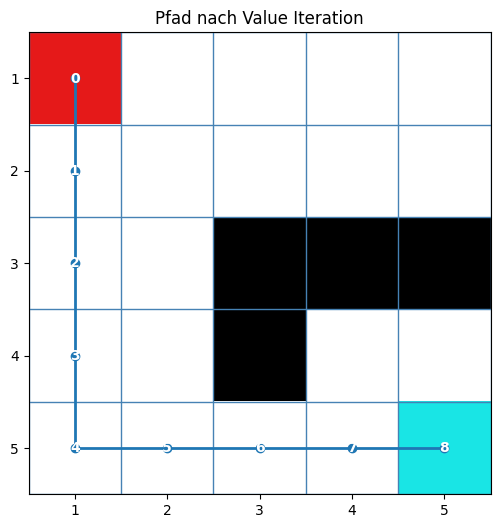

In [7]:
def plot_path(path):
    fig, ax = plt.subplots(figsize=(6, 6))
    draw_grid(ax)

    xs = [c for r, c in path]
    ys = [r for r, c in path]

    ax.plot(xs, ys, marker="o", linewidth=2)
    for i, (r, c) in enumerate(path):
        ax.text(c, r, str(i), ha="center", va="center", color="white", fontweight="bold")

    ax.set_title("Pfad nach Value Iteration")
    plt.show()

plot_path(path)

## 7. Was du hier mitnehmen solltest

- **Value Iteration** berechnet für jeden Zustand, wie gut er langfristig ist.
- Daraus kann man direkt die **beste Aktion pro Zustand** ableiten.
- Das funktioniert gut bei **kleinen, diskreten** Problemen.
- Für große oder kontinuierliche Robotik-Probleme nutzt man später oft andere Verfahren.

### Kleine Übung
Ändere einmal:
- `step_reward`
- `goal_reward`
- die Hindernisse
- `gamma`

und beobachte, wie sich Werte und Pfad ändern.